In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import sys

import matplotlib.pyplot as plt
from dotenv import load_dotenv

import os
import xml.etree.ElementTree as ET
from pathlib import Path

ROOT_DIR = Path.cwd().parent.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))
    
from scripts.src.operations.connections import _get_pasta_data
from typing import Tuple, Dict

import scripts.src.inputs.config as cfg
from scripts.src.helpers import parse_edges
import sumolib
import math

In [52]:
data_folder = Path("/media/fullsuper/ExternalDisk1/irene/dtSumo/data/sensors")

if data_folder is not None:
    anagrafica = pd.read_csv(Path(data_folder / "anagrafica.csv")) 
    flows = pd.read_csv(Path(data_folder / "flows.csv")) 
else:
    load_dotenv()  # reads variables from a .env file and sets them in os.environ
    connection_strings = {
        "ista": os.getenv("ISTA_URL"),
        "istc": os.getenv("ISTC_URL"),
    }
    anagrafica, flows = _get_pasta_data(connection_strings['ista'], connection_strings['istc'])

gdf_sens = gpd.GeoDataFrame(
    anagrafica,
    geometry=gpd.points_from_xy(anagrafica.lon, anagrafica.lat),
    crs="EPSG:4326",
).to_crs(epsg=3857)

#gdf_sens['shape'] = (gdf_sens.geometry)
gdf_sens

,Cod_sens,sezione,name,strada,direction,sensor_description,lat,lon,disponibile,geometry
0,417,2,Francia / Massaua,c.Francia,centro,3475178611,45.074371,7.615753,True,POINT (847781.746 5633237.287)
1,428,2,Francia / Marche,c.Francia,centro,3477966219,45.074194,7.612636,True,POINT (847434.763 5633209.385)
2,1009,107,TRR01 - TRAPANI/PESCHIERA\r\n,Corso Trapani,verso Corso Lecce,sensore ENGINE,45.068710,7.638480,True,POINT (850311.704 5632344.963)
3,1010,108,TRR02 - TRAPANI/PESCHIERA\r\n,Corso Peschiera,verso esterno città,sensore ENGINE,45.068830,7.638840,True,POINT (850351.779 5632363.877)
4,1011,109,TRR03 - TRAPANI/PESCHIERA\r\n,Corso Peschiera,verso centro città,sensore ENGINE,45.069020,7.638170,True,POINT (850277.195 5632393.825)
5,1012,110,TRR04 - TRAPANI/PESCHIERA\r\n,Corso Trapani,verso Corso Siracusa,sensore ENGINE,45.069130,7.638550,True,POINT (850319.496 5632411.163)
6,1013,111,LEA01 - LECCE/APPIO CLAUDIO\r\n,Corso Lecce,verso Corso Trapani,sensore ENGINE,45.085110,7.649940,True,POINT (851587.425 5634930.28)
7,1014,112,LEA02 - LECCE/APPIO CLAUDIO\r\n,Corso Lecce,verso Corso Potenza,sensore ENGINE,45.084670,7.649810,True,POINT (851572.954 5634860.908)
8,73191,10701011,B0711 Telesio / Francia,corso Telesio,NORD,sensore FEP_BRIDGE,45.075090,7.624580,True,POINT (848764.363 5633350.626)
9,73192,10701031,B0713 Brunelleschi / Francia,corso Brunelleschi,SUD,sensore FEP_BRIDGE,45.074400,7.623590,True,POINT (848654.157 5633241.858)


In [53]:
import xml.etree.ElementTree as ET
import sumolib
import pandas as pd

net = sumolib.net.readNet(cfg.NET_FILE)
tree = ET.parse("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_PM/incremental/netload_r0.xml")  # il file netload dello scenario/periodo in questione

rows = []
for interval in tree.getroot().findall("interval"):
    for edge_el in interval.findall("edge"):
        eid = edge_el.get("id")
        ratio = edge_el.get("flowCapacityRatio")
        if ratio is None:
            continue
        ratio = float(ratio)
        if not net.hasEdge(eid):
            continue
        e = net.getEdge(eid)
        rows.append({
            "edge": eid,
            "flowCapacityRatio": ratio,
            "priority": e.getPriority(),
            "numLanes": e.getLaneNumber(),
            "speed": e.getSpeed(),
        })

df = pd.DataFrame(rows)

saturated = df[df["flowCapacityRatio"] >= 100]
priority_media_rete = df["priority"].mean()
priority_media_saturi = saturated["priority"].mean()

print(f"Priorità media di TUTTA la rete: {priority_media_rete:.1f}")
print(f"Priorità media edge saturi: {priority_media_saturi:.1f}")

Priorità media di TUTTA la rete: 4.7
Priorità media edge saturi: 4.0


In [54]:
def load_netload(netload_path: Path):
    tree = ET.parse(netload_path)
    root = tree.getroot()

    rows = []

    for t in root.findall("interval"):
        begin = t.attrib.get("begin")
        end = t.attrib.get("end")

        for e in t.findall("edge"):
            rows.append({
                "begin": begin,
                "end": end,
                "id": e.attrib.get("id"),
                "traveltime": float(e.attrib.get("traveltime")),
                "speed": float(e.attrib.get("speed")),
                "speedRelative": float(e.attrib.get("speedRelative")),
                "entered": float(e.attrib.get("entered")),
                "density": float(e.attrib.get("density")),
                "laneDensity": float(e.attrib.get("laneDensity")),
                "flowCapacityRatio": float(e.attrib.get("flowCapacityRatio")),
            })

    return pd.DataFrame(rows)

df_netload_r0 = load_netload("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/incremental/netload_r0.xml")
df_netload_r1 = load_netload("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/incremental/netload_r1.xml")
df_netload_r2 = load_netload("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/incremental/netload_r2.xml")  
df_netload_r3 = load_netload("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/incremental/netload_r3.xml") 
df_netload_r4 = load_netload("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/incremental/netload_r4.xml")   

FileNotFoundError: [Errno 2] No such file or directory: '/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/incremental/netload_r1.xml'

In [ ]:
def summarize(df, label):
    over100 = df[df["flowCapacityRatio"] > 100]
    excess = (df["flowCapacityRatio"] - 100).clip(lower=0).sum()  # "sovraccarico" totale, un solo numero
    print(f"--- {label} ---")
    print(f"Edge >100%: {len(over100)} / {len(df)}")
    print(f"Edge >150%: {(df['flowCapacityRatio'] > 150).sum()}")
    print(f"Somma eccesso (ratio-100 sommato sugli edge saturi): {excess:.0f}")
    print(f"flowCapacityRatio mediano: {df['flowCapacityRatio'].median():.1f}")
    print(f"Velocità media pesata sugli edge percorsi: {(df['speed']*df['entered']).sum()/df['entered'].sum():.1f} m/s")
    return over100

over_r0 = summarize(df_netload_r0, "AM incr. round 0")
over_r1 = summarize(df_netload_r1, "AM incr. round 1")
over_r2 = summarize(df_netload_r2, "AM incr. round 2")
over_r3 = summarize(df_netload_r3, "AM incr. round 3")
over_r4 = summarize(df_netload_r4, "AM incr. round 4")

--- AM incr. round 0 ---
Edge >100%: 29 / 2529
Edge >150%: 8
Somma eccesso (ratio-100 sommato sugli edge saturi): 1278
flowCapacityRatio mediano: 6.9
Velocità media pesata sugli edge percorsi: 8.1 m/s
--- AM incr. round 1 ---
Edge >100%: 77 / 2529
Edge >150%: 29
Somma eccesso (ratio-100 sommato sugli edge saturi): 3989
flowCapacityRatio mediano: 4.6
Velocità media pesata sugli edge percorsi: 6.5 m/s
--- AM incr. round 2 ---
Edge >100%: 44 / 2529
Edge >150%: 17
Somma eccesso (ratio-100 sommato sugli edge saturi): 2231
flowCapacityRatio mediano: 5.2
Velocità media pesata sugli edge percorsi: 7.0 m/s
--- AM incr. round 3 ---
Edge >100%: 64 / 2529
Edge >150%: 26
Somma eccesso (ratio-100 sommato sugli edge saturi): 3054
flowCapacityRatio mediano: 4.2
Velocità media pesata sugli edge percorsi: 6.7 m/s
--- AM incr. round 4 ---
Edge >100%: 57 / 2529
Edge >150%: 22
Somma eccesso (ratio-100 sommato sugli edge saturi): 2672
flowCapacityRatio mediano: 6.6
Velocità media pesata sugli edge percorsi:

In [ ]:
import re
from collections import Counter

log = "/media/fullsuper/ExternalDisk1/irene/sumo_run.log"

teleport_by_edge = Counter()
pattern = re.compile(r"Teleporting vehicle '([^']+)'.*?lane='([^']+)'")

with open(log, encoding="utf-8", errors="ignore") as f:
    for line in f:
        if "Teleporting" not in line:
            continue
        m = pattern.search(line)
        if m:
            veh_id, lane_id = m.groups()
            edge_id = lane_id.rsplit("_", 1)[0]  # rimuove l'indice di corsia finale (_0, _1...)
            teleport_by_edge[edge_id] += 1

print(f"Eventi di teleport: {sum(teleport_by_edge.values())}")
print("Top 20 edge per numero di teleport:")
for edge, count in teleport_by_edge.most_common(20):
    print(f"  {edge}: {count}")

Eventi di teleport: 20503
Top 20 edge per numero di teleport:
  1113770113#1: 491
  121952561#1: 422
  121952561#2: 406
  154986388#3: 283
  121952561#3: 263
  1305474659#3: 225
  154986388#1: 222
  1305812799#0: 220
  1305812799#1: 220
  1113770118#2: 208
  1113770114#3: 204
  154986388#0: 185
  1113770114#1: 174
  1113770112#2: 160
  -447701119#1: 160
  81240122: 155
  -150260120#0: 147
  889379655: 142
  58414209#1: 139
  447701120#0: 138


In [ ]:
saturated_edges = set(df_netload_r0[df_netload_r0["flowCapacityRatio"] > 100]["id"])  # dal check già fatto prima
teleport_edges = set(teleport_by_edge.keys())

overlap = saturated_edges & teleport_edges
print(f"Edge saturi che coincidono con edge dove avvengono teleport: {len(overlap)}/{len(saturated_edges)}")

teleport_on_saturated = sum(teleport_by_edge[e] for e in overlap)
total = sum(teleport_by_edge.values())
print(f"Quota di TUTTI i teleport che avviene su edge già segnalati come saturi: {teleport_on_saturated/total:.1%}")

Edge saturi che coincidono con edge dove avvengono teleport: 8/29
Quota di TUTTI i teleport che avviene su edge già segnalati come saturi: 0.5%


In [55]:
import re

def base_street_id(edge_id):
    m = re.match(r"-?(\d+)", edge_id)
    return m.group(1) if m else edge_id

from collections import Counter
street_teleports = Counter()
for edge, count in teleport_by_edge.items():
    street_teleports[base_street_id(edge)] += count

print("Top 15 edges per teleport:")
for street, count in street_teleports.most_common(15):
    print(f"  {street}: {count}")

Top 15 edges per teleport:
  121952561: 1205
  154986388: 754
  1305812799: 499
  1113770113: 491
  667668276: 404
  1307721869: 397
  1113770114: 379
  1311144281: 357
  397430750: 285
  1307502578: 258
  1307179604: 249
  447701120: 245
  150260120: 243
  1305474659: 235
  1113770118: 234


In [56]:
import xml.etree.ElementTree as ET
import sumolib

net = sumolib.net.readNet(cfg.NET_FILE)
tree = ET.parse("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_PM/incremental/netload_r7.xml")

rows = []
for interval in tree.getroot().findall("interval"):
    for edge_el in interval.findall("edge"):
        eid = edge_el.get("id")
        ratio = float(edge_el.get("flowCapacityRatio", 0))
        if ratio > 100:
            e = net.getEdge(eid)
            rows.append({
                "edge": eid,
                "flowCapacityRatio": ratio,
                "priority": e.getPriority(),
                "numLanes": e.getLaneNumber(),
                "speed": e.getSpeed(),
            })

df = pd.DataFrame(rows).sort_values("flowCapacityRatio", ascending=False)
print(df.head(30))
print(f"\nPriorità media edge saturi: {df['priority'].mean():.1f}")
print(f"Priorità media di TUTTA la rete: {sum(e.getPriority() for e in net.getEdges())/len(net.getEdges()):.1f}")

             edge  flowCapacityRatio  priority  numLanes  speed
20   1167094068#1             276.62         4         1  11.11
14    -42212708#3             212.37         4         1  13.89
15    -42212708#4             212.37         4         1  13.89
16    -42212708#5             212.37         4         1  13.89
40      4761525#6             212.37         4         1  13.89
41      4761525#8             212.37         4         1  13.89
38      4761525#2             212.37         4         1  13.89
39      4761525#3             212.37         4         1  13.89
28      134572343             211.54         4         1  13.89
36      418320704             199.88         4         1  13.89
30      208420936             189.77         5         1  13.89
10      -36357295             173.31         4         1  13.89
4    -116647088#5             169.82         4         1  13.89
24  1311144281#17             155.48         4         1  11.11
27    134460789#6             155.19    

In [57]:
top_edges = (
    df_netload.groupby("id")["flowCapacityRatio"]
    .max()
    .sort_values(ascending=False)
    .head(20)
)
print(top_edges)

id
4761525#6       2896.50
4761525#8       2896.50
-42212708#4     2896.00
-42212708#5     2896.00
-42212708#3     2896.00
154986384#0     2182.35
-42212708#1     2102.27
-42212708#0     2102.27
1167094068#1    1934.33
1167094068#2    1934.33
1167094068#3    1934.33
134460789#10    1601.53
134460789#9     1601.53
-36357295       1586.95
1167094068#4    1573.41
1167094068#5    1535.34
-116647088#5    1522.45
111596716       1494.52
-42212707       1489.73
116647088#5     1466.58
Name: flowCapacityRatio, dtype: float64


## GEH index

In [58]:
SCALE_BY = 1.0
flows['count_all'] = flows['count_all'] * SCALE_BY
hour_mean_flows = pd.DataFrame(flows.groupby(by=['Cod_sens', 'hour'])['count_all'].mean())
hour_mean_flows

count_all
Cod_sens hour           
192      0      0.000000
         1      0.000000
         2      1.666667
         3      1.400000
         4      1.666667
...                  ...
130233   19    26.800000
         20    23.066667
         21    13.333333
         22     9.666667
         23    10.600000

[13838 rows x 1 columns]

In [59]:
sensor_lane_lookup = pd.read_csv(cfg.SENS_LANE_LOOKUP)
df_netload = load_netload("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_with_TLS_DAY/netload_ouput.xml")


In [60]:
# edges_to_check = set(sensor_lane_lookup['id_edge'])
edge_sensor = sensor_lane_lookup[["Cod_sens", "id_edge"]].drop_duplicates()
edge_sensor

# df = df_netload.where(df_netload['id'].isin(edges_to_check))
df_filtered = df_netload[df_netload['id'].isin(edge_sensor['id_edge'])].reset_index(drop=True)
df_filtered

,begin,end,id,traveltime,speed,speedRelative,entered,density,laneDensity,flowCapacityRatio
0,0.00,3600.00,-1307179596,5.58,22.17,1.00,40.00,0.50,0.17,1.67
1,0.00,3600.00,-1307179610#2,0.08,22.18,1.00,31.00,0.39,0.13,1.29
2,0.00,3600.00,121952543#1,7.22,22.15,1.00,56.00,0.70,0.23,2.33
3,0.00,3600.00,121952544#1,9.95,21.96,0.99,136.00,1.72,0.86,8.50
4,0.00,3600.00,121952560#1,12.84,22.11,1.00,57.00,0.72,0.36,3.56
...,...,...,...,...,...,...,...,...,...,...
451,82800.00,86400.00,1311410663#0,26.43,11.11,1.00,0.00,0.00,0.00,0.00
452,82800.00,86400.00,134420434#1,1.19,12.76,0.66,6115.78,133.12,66.56,382.24
453,82800.00,86400.00,257357078#0,0.48,13.89,1.00,0.00,0.00,0.00,0.00
454,82800.00,86400.00,38319544#26,2.38,13.15,0.68,5584.24,117.97,58.98,349.02


In [61]:
df_merged = df_filtered.merge(edge_sensor, left_on="id", right_on="id_edge")
df_merged

,begin,end,id,traveltime,speed,speedRelative,entered,density,laneDensity,flowCapacityRatio,Cod_sens,id_edge
0,0.00,3600.00,-1307179596,5.58,22.17,1.00,40.00,0.50,0.17,1.67,73199,-1307179596
1,0.00,3600.00,-1307179610#2,0.08,22.18,1.00,31.00,0.39,0.13,1.29,1011,-1307179610#2
2,0.00,3600.00,121952543#1,7.22,22.15,1.00,56.00,0.70,0.23,2.33,417,121952543#1
3,0.00,3600.00,121952544#1,9.95,21.96,0.99,136.00,1.72,0.86,8.50,73193,121952544#1
4,0.00,3600.00,121952560#1,12.84,22.11,1.00,57.00,0.72,0.36,3.56,73196,121952560#1
...,...,...,...,...,...,...,...,...,...,...,...,...
571,82800.00,86400.00,134420434#1,1.19,12.76,0.66,6115.78,133.12,66.56,382.24,73191,134420434#1
572,82800.00,86400.00,257357078#0,0.48,13.89,1.00,0.00,0.00,0.00,0.00,1013,257357078#0
573,82800.00,86400.00,257357078#0,0.48,13.89,1.00,0.00,0.00,0.00,0.00,1014,257357078#0
574,82800.00,86400.00,38319544#26,2.38,13.15,0.68,5584.24,117.97,58.98,349.02,95577,38319544#26


In [62]:
import numpy as np

def geh_index(df_sim, df_real, name, metric="entered"):
    df_sim_copy = df_sim.dropna(subset=[metric]).copy()
    
    df_sim_copy["begin"] = pd.to_numeric(df_sim_copy["begin"], errors="coerce")
    df_sim_copy[metric]  = pd.to_numeric(df_sim_copy[metric],  errors="coerce")
    
    df_sim_copy["hour"] = (df_sim_copy["begin"] // 3600).astype(int)
    
    # se un sensore mappa su più edge somma i veicoli, fa media per la speed
    agg_func = "sum" if metric == "entered" else "mean"
    df_sim_hourly = df_sim_copy.groupby("hour")[metric].agg(agg_func)

    df_real_filtered = df_real.xs(key=name, level="Cod_sens")

    n_sim, n_real = len(df_sim_hourly), len(df_real_filtered)
    df_sim_hourly, df_real_filtered = df_sim_hourly.align(df_real_filtered, join="inner")
    if len(df_sim_hourly) < min(n_sim, n_real):
        print(f"[WARN] {name}: solo {len(df_sim_hourly)}/{min(n_sim, n_real)} ore allineate")

    sim_val = df_sim_hourly.values.flatten()
    real_val = df_real_filtered.values.flatten()

    denom = sim_val + real_val
    geh = np.sqrt(np.divide(
        2 * (sim_val - real_val) ** 2, denom,
        out=np.zeros_like(denom, dtype=float),
        where=denom > 0,
    ))

    return pd.DataFrame({
        "Cod_sens": name,
        "hour": df_sim_hourly.index.values,
        "Simulated": sim_val,
        "Real": real_val,
        "GEH": geh,
    })

In [63]:
geh_list = []
for name, df_sim in df_merged.groupby("Cod_sens"):
    df_geh = geh_index(df_sim, hour_mean_flows, name, metric="entered")
    geh_list.append(df_geh)

df_geh_all = pd.concat(geh_list, ignore_index=True)
df_geh_all

,Cod_sens,hour,Simulated,Real,GEH
0,417,0,56.00,175.263158,11.090933
1,417,1,84.00,77.210526,0.756231
2,417,2,103.00,48.263158,6.294021
3,417,3,119.00,41.421053,8.662200
4,417,4,151.00,67.473684,7.991692
...,...,...,...,...,...
571,95577,19,5059.74,352.050000,90.500793
572,95577,20,5253.54,210.350000,96.487122
573,95577,21,5379.54,134.100000,99.902813
574,95577,22,5493.12,107.900000,101.761825


In [64]:
df_geh['diff'] = df_geh['Simulated'] - df_geh['Real']
bias_orario = df_geh.groupby('hour')['diff'].mean()
bias_orario

hour
0        1.950000
1       44.800000
2       70.900000
3       82.350000
4      105.850000
5      180.050000
6      344.500000
7      711.950000
8     1280.200000
9     1817.090000
10    2001.010000
11    2249.810000
12    2527.140000
13    2831.700000
14    3087.370000
15    3361.590000
16    3657.200000
17    3973.845263
18    4337.090000
19    4707.690000
20    5043.190000
21    5245.440000
22    5385.220000
23    5499.340000
Name: diff, dtype: float64

In [65]:
ratio = df_geh.groupby('hour').apply(lambda g: g['Simulated'].sum() / g['Real'].sum())
ratio

/tmp/ipykernel_2905611/885534608.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratio = df_geh.groupby('hour').apply(lambda g: g['Simulated'].sum() / g['Real'].sum())


hour
0      1.047503
1      3.461538
2     10.985915
3     10.520231
4     10.493274
5      5.396825
6      4.175115
7      3.281525
8      4.139284
9      6.490527
10     7.519010
11     8.329565
12     9.546297
13    11.933205
14    11.221387
15    11.072180
16    10.603992
17    10.200958
18    10.971468
19    14.372220
20    24.975232
21    40.115884
22    50.909361
23    65.774323
dtype: float64

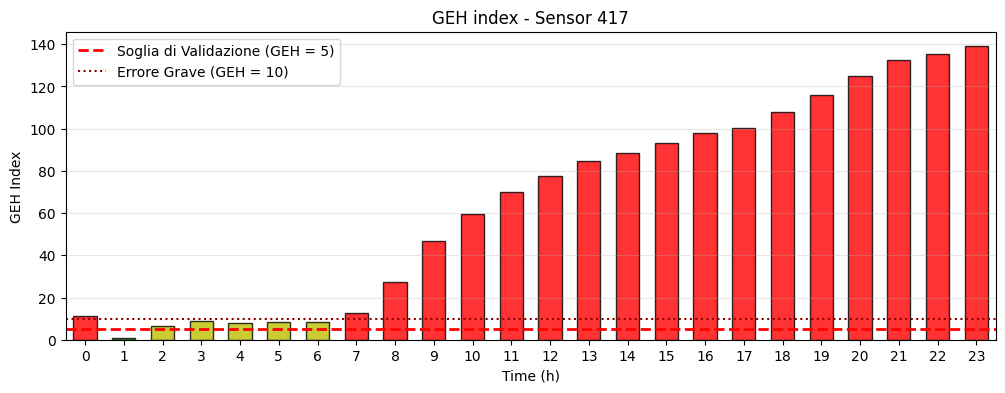

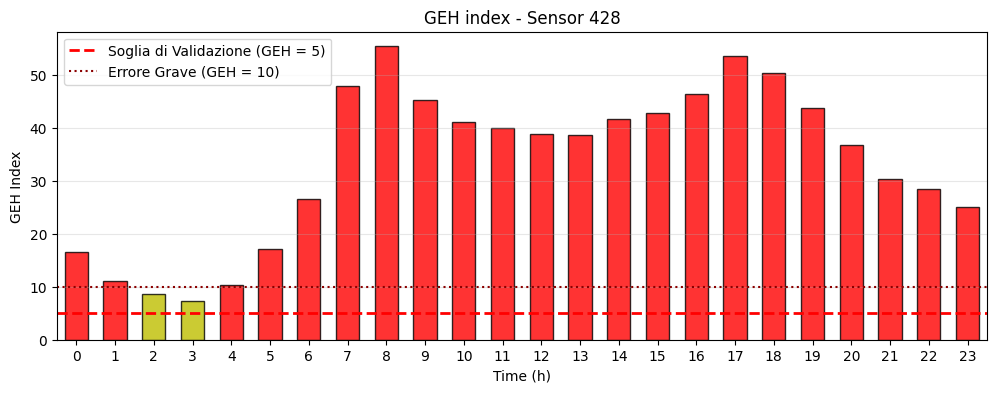

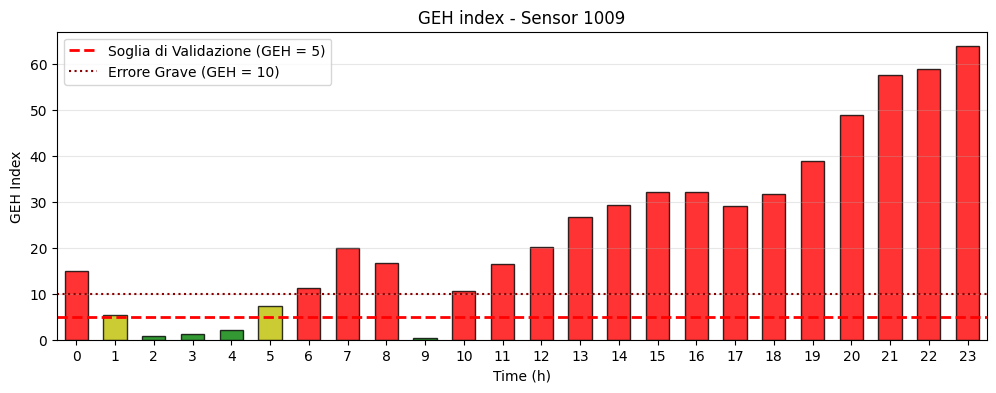

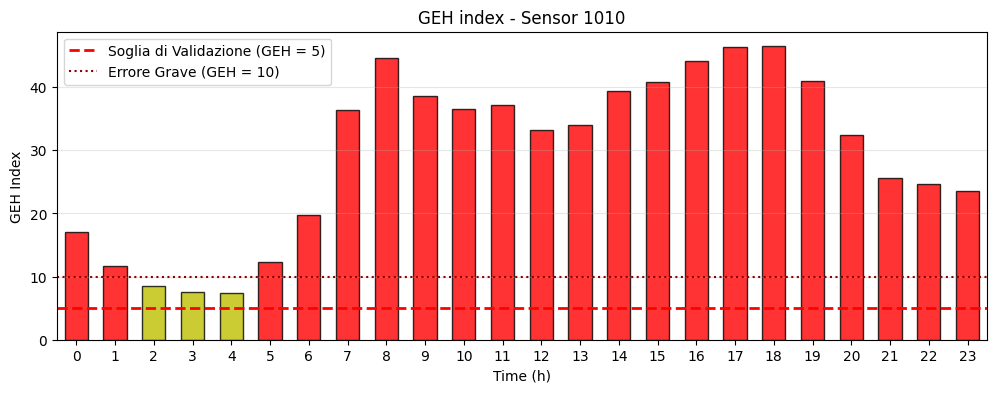

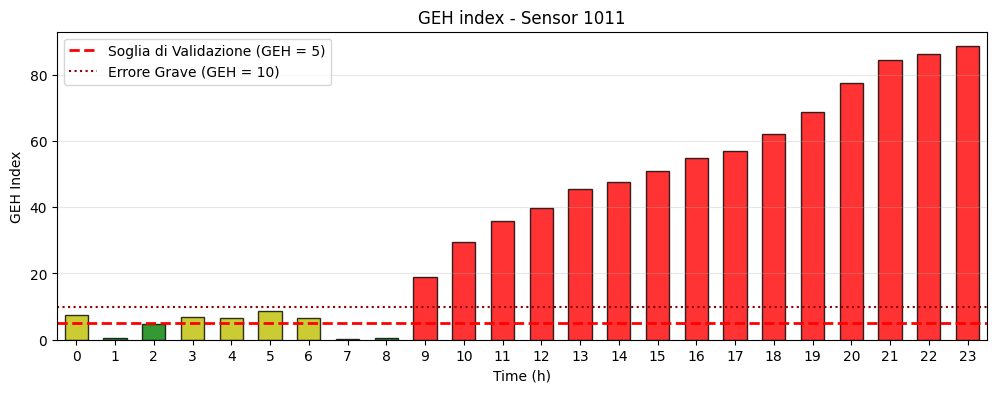

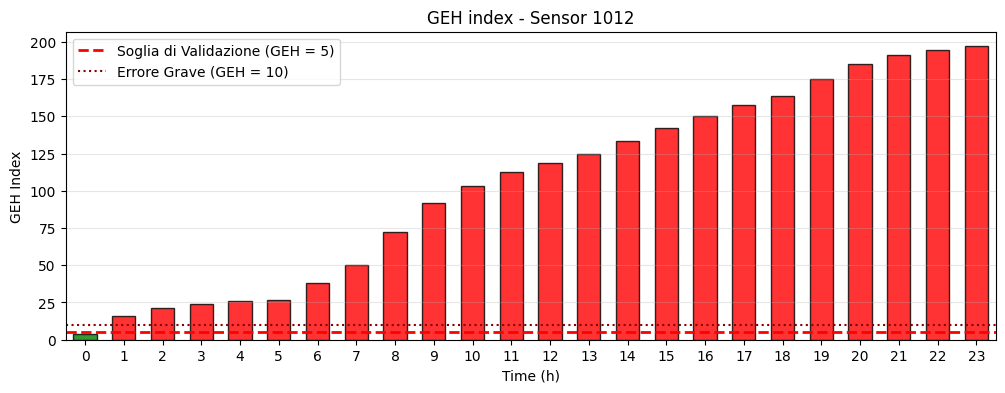

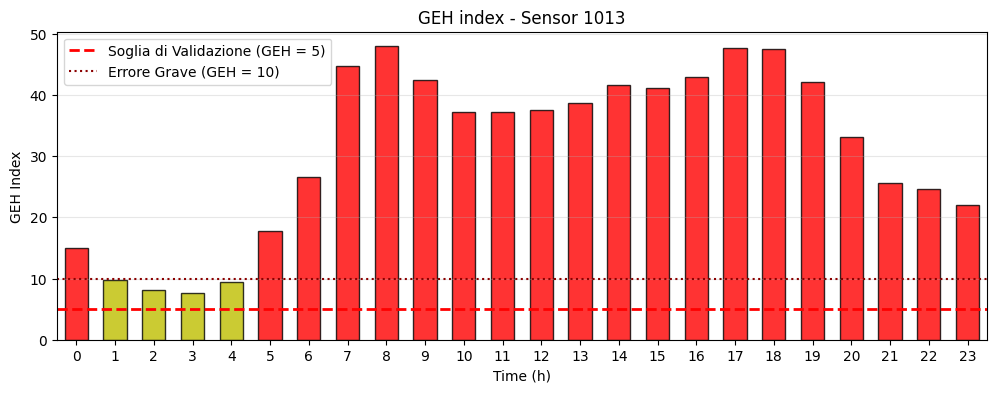

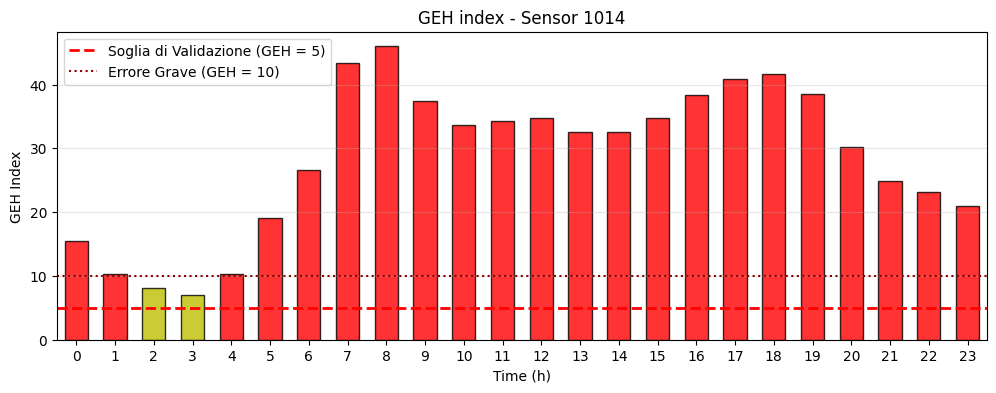

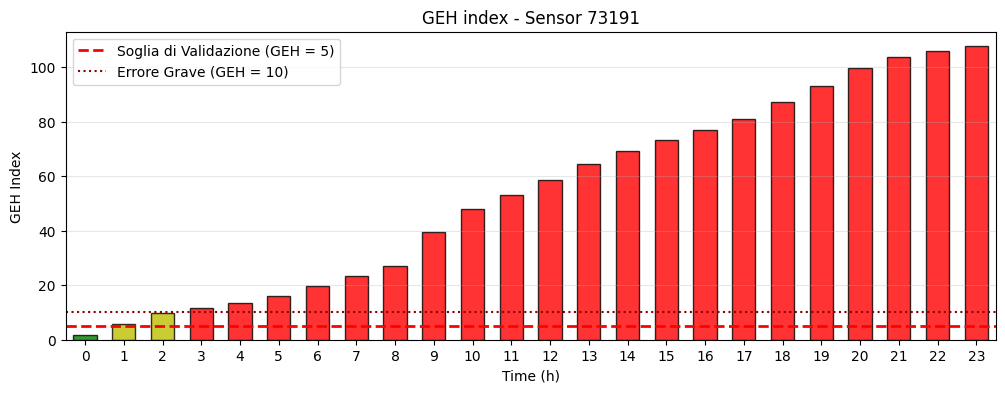

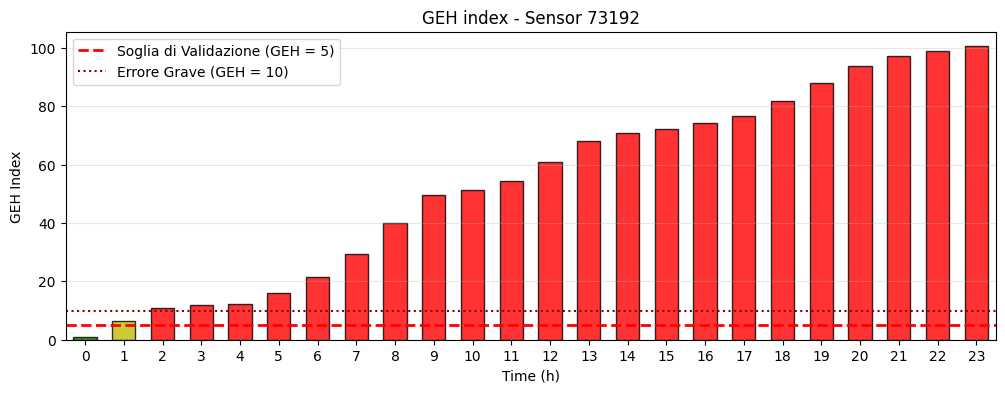

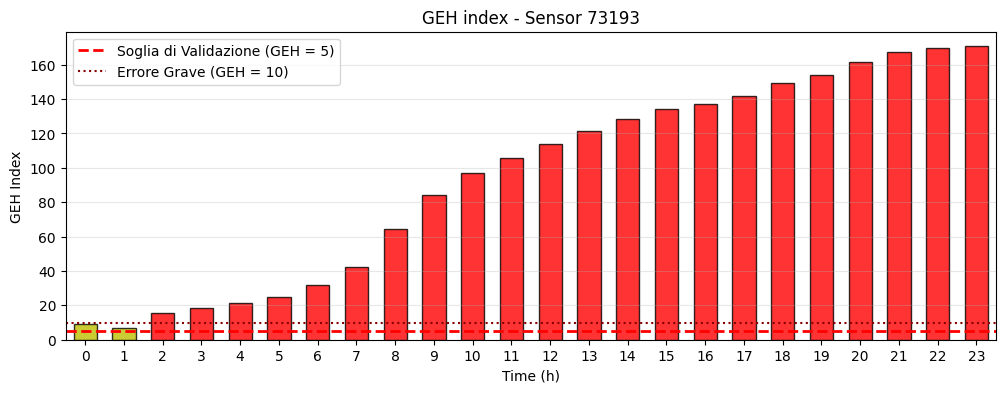

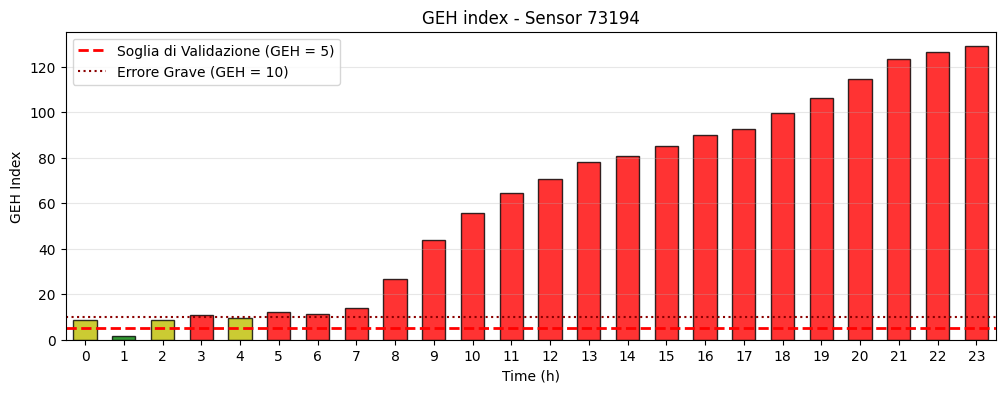

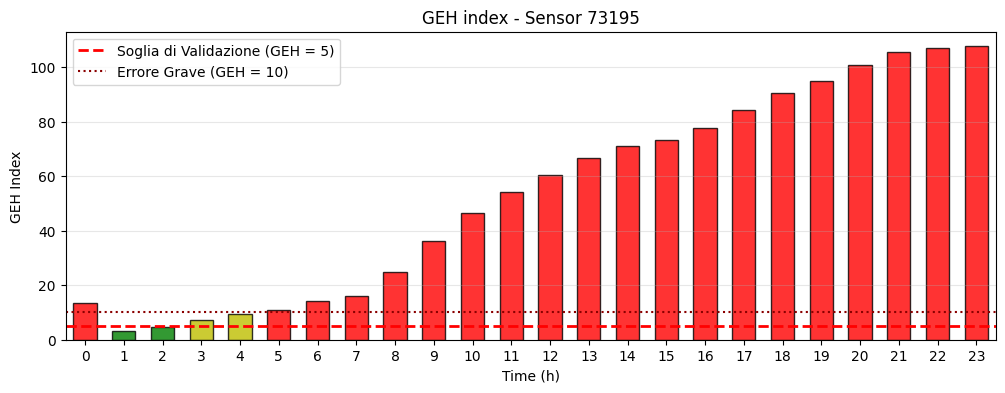

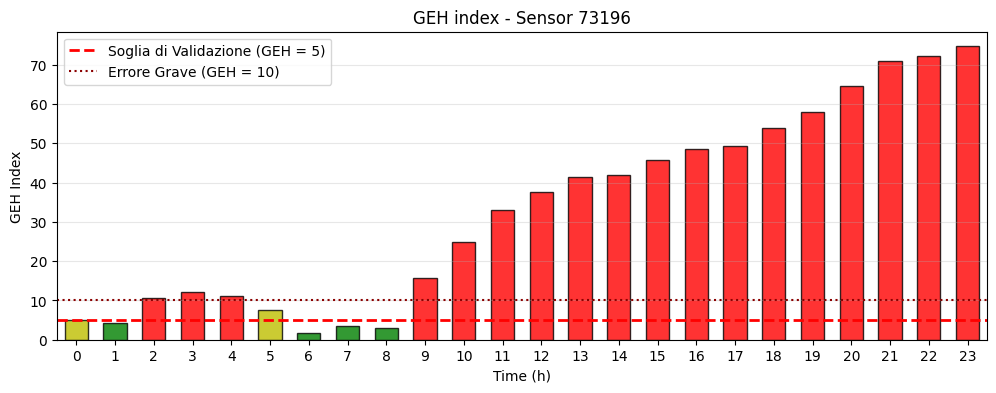

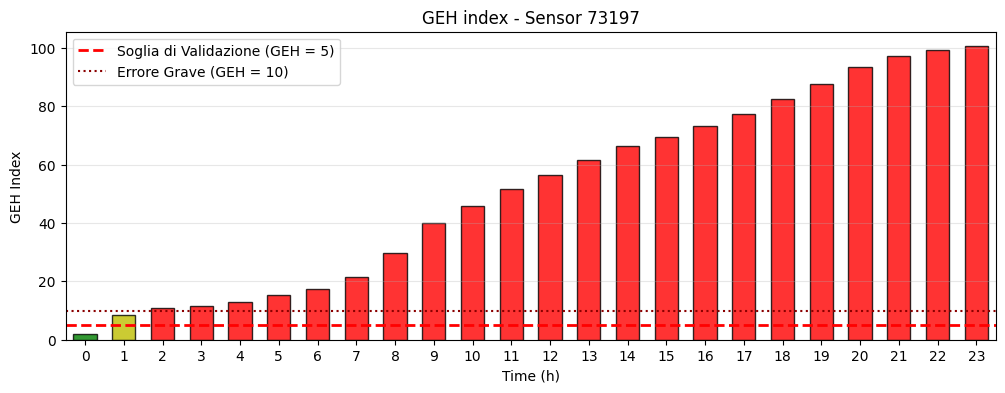

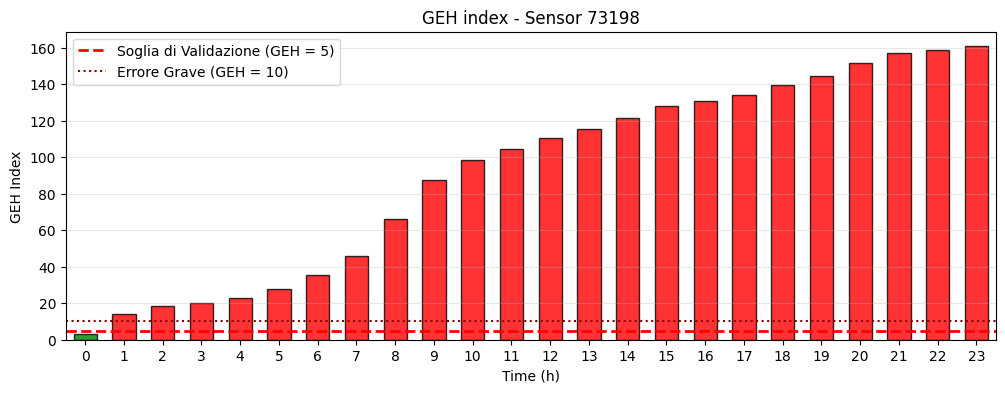

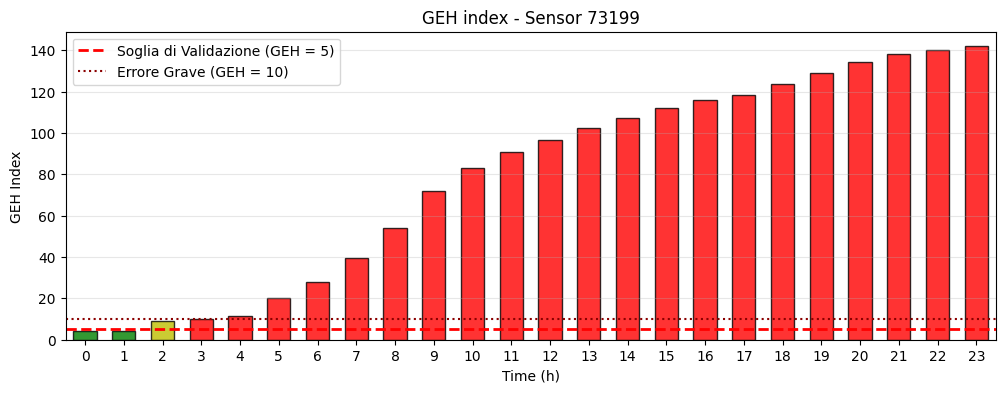

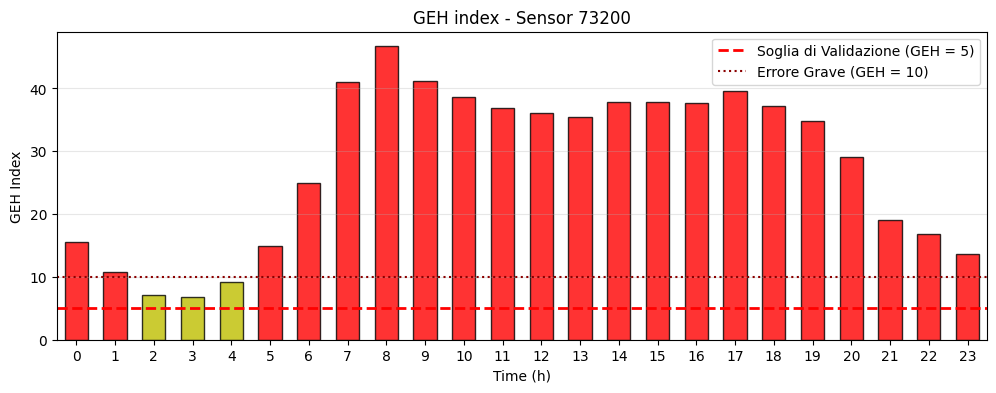

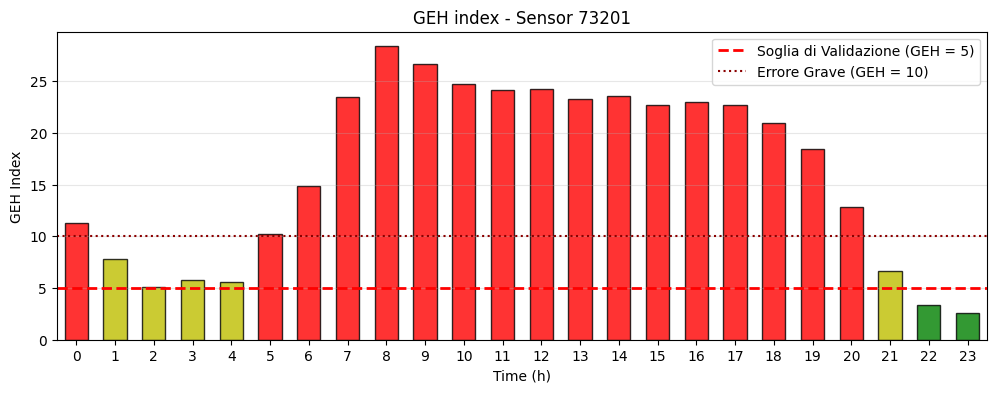

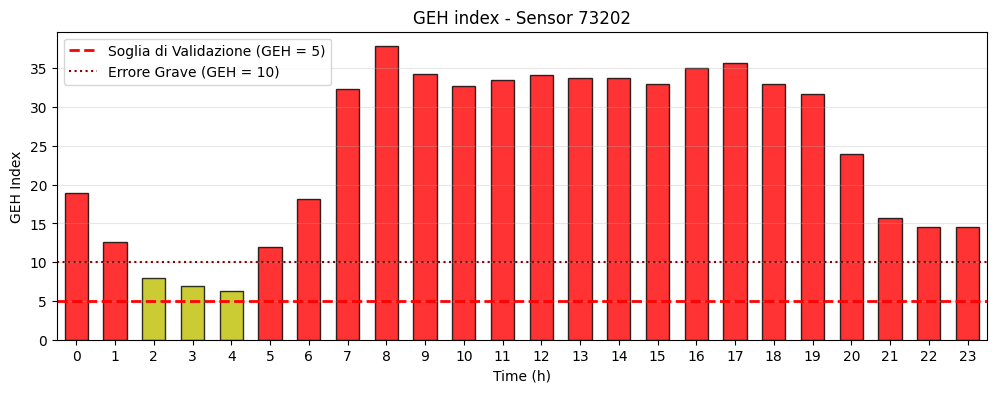

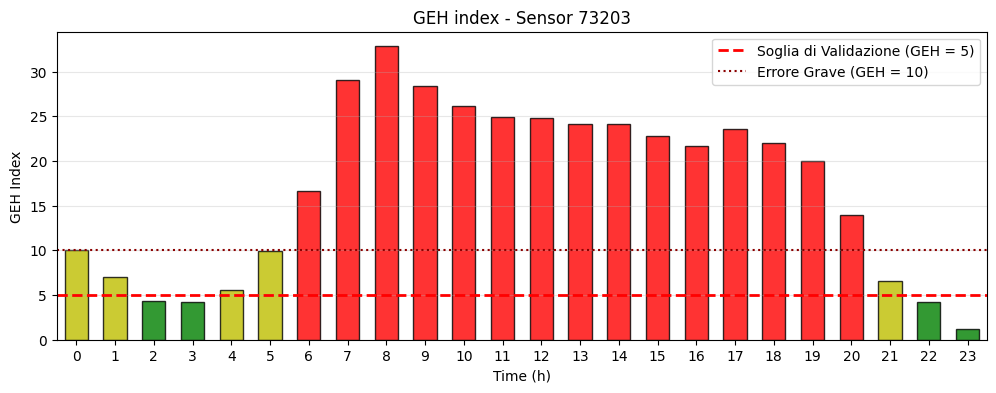

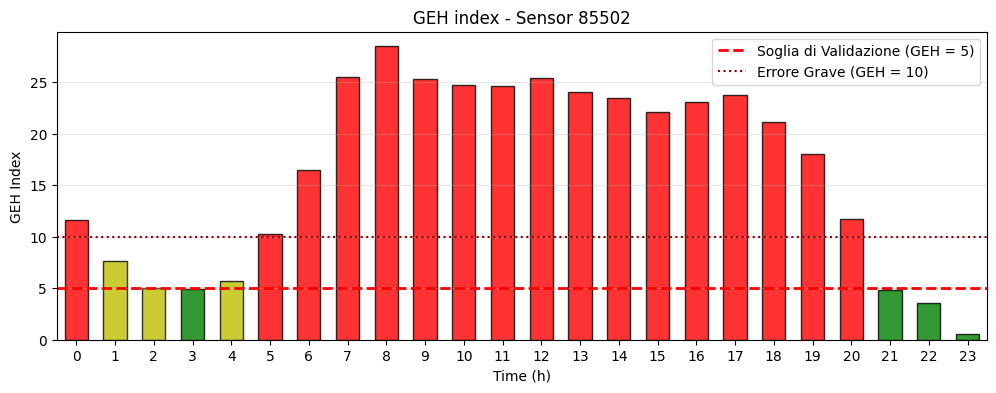

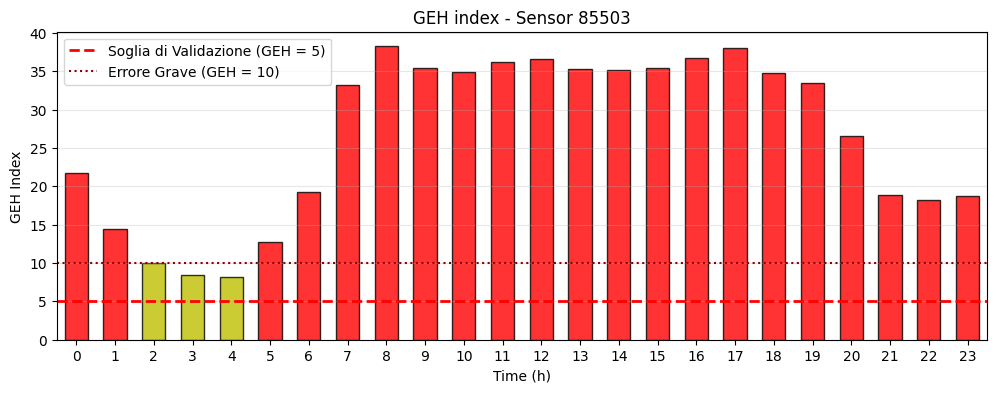

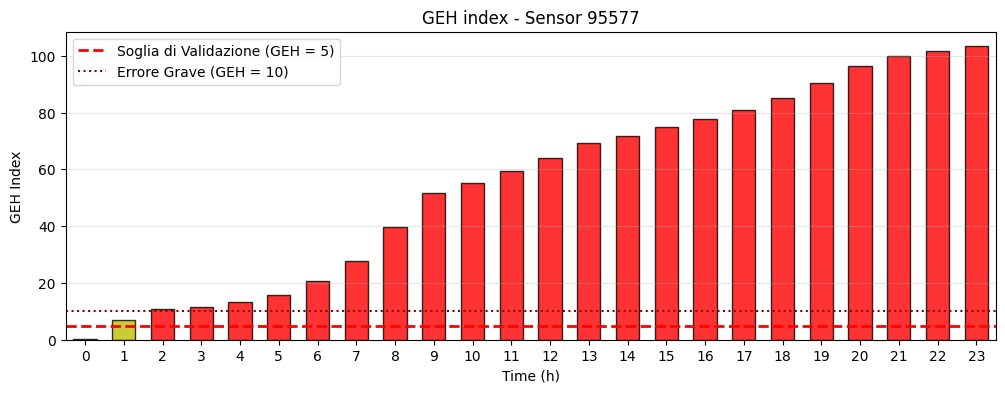

In [66]:
import matplotlib.pyplot as plt

def plot_geh_hourly(df_geh, name):
    """
    Prende in input il DataFrame complessivo di tutti i sensori,
    lo filtra per il sensore specificato e genera un grafico a barre orario del GEH.
    """
    if df_geh is None or df_geh.empty: 
        return
    
    # 1. Filtriamo IMMEDIATAMENTE i dati per il sensore corrente
    df_geh_filtered = df_geh[df_geh['Cod_sens'] == name]
    
    if df_geh_filtered.empty:
        print(f"No data related to GEH index for sensor {name}")
        return

    # 2. Generiamo i colori SOLO sulle righe del sensore filtrato
    colors = ['g' if x < 5 else 'y' if x <= 10 else 'r' for x in df_geh_filtered['GEH']]
    
    plt.figure(figsize=(12, 4))
    
    plt.bar(df_geh_filtered['hour'], df_geh_filtered['GEH'], color=colors, alpha=0.8, edgecolor='black', width=0.6)
    plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Soglia di Validazione (GEH = 5)')
    plt.axhline(y=10, color='darkred', linestyle=':', linewidth=1.5, label='Errore Grave (GEH = 10)')
    
    # Formattazione assi
    plt.xlim(-0.5, 23.5)
    plt.xticks(range(0, 24))
    plt.xlabel('Time (h)')
    plt.ylabel('GEH Index')
    plt.title(f'GEH index - Sensor {name}')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.show()

for name, df_geh_sensor in df_geh_all.groupby("Cod_sens"):
    plot_geh_hourly(df_geh_sensor, name)

In [67]:
import sumolib
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.pyplot as plt

net = sumolib.net.readNet(str(cfg.NET_FILE))
edge_shapes = {e.getID(): e.getShape() for e in net.getEdges()}

Text(0.5, 1.0, 'Edge oltre capacità nel netload (n=1095), spessore ∝ gravità')

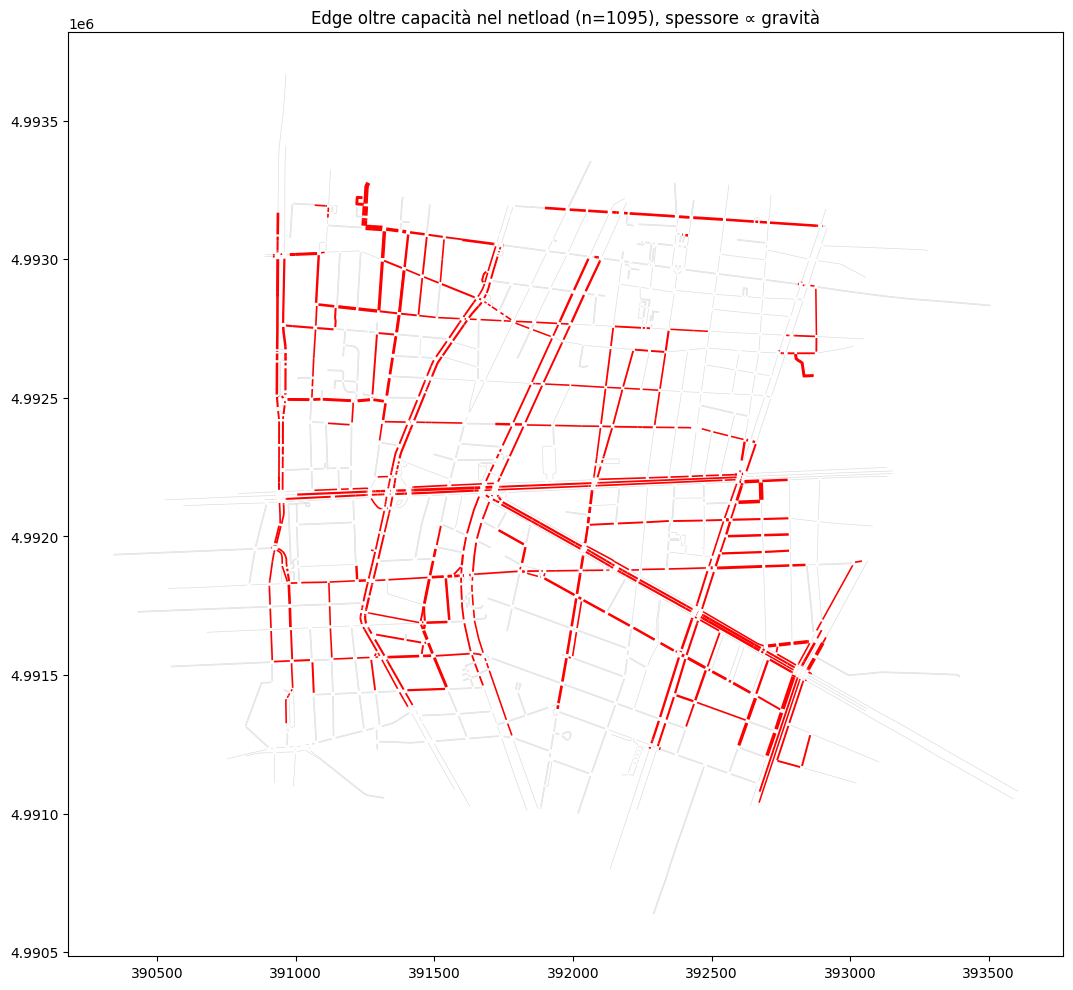

In [68]:
critical = df_netload.groupby("id")["flowCapacityRatio"].max()
critical = critical[critical > 100]

fig, ax = plt.subplots(figsize=(16, 12))
ax.add_collection(LineCollection(list(edge_shapes.values()), colors="#dddddd", linewidths=0.5))
for eid, ratio in critical.items():
    if eid in edge_shapes:
        ax.add_collection(LineCollection(
            [edge_shapes[eid]], colors="red", linewidths=1 + 3 * (ratio / critical.max())
        ))
ax.autoscale(); ax.set_aspect("equal")
ax.set_title(f"Edge oltre capacità nel netload (n={len(critical)}), spessore ∝ gravità")

/tmp/ipykernel_2905611/1932275724.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn_r")


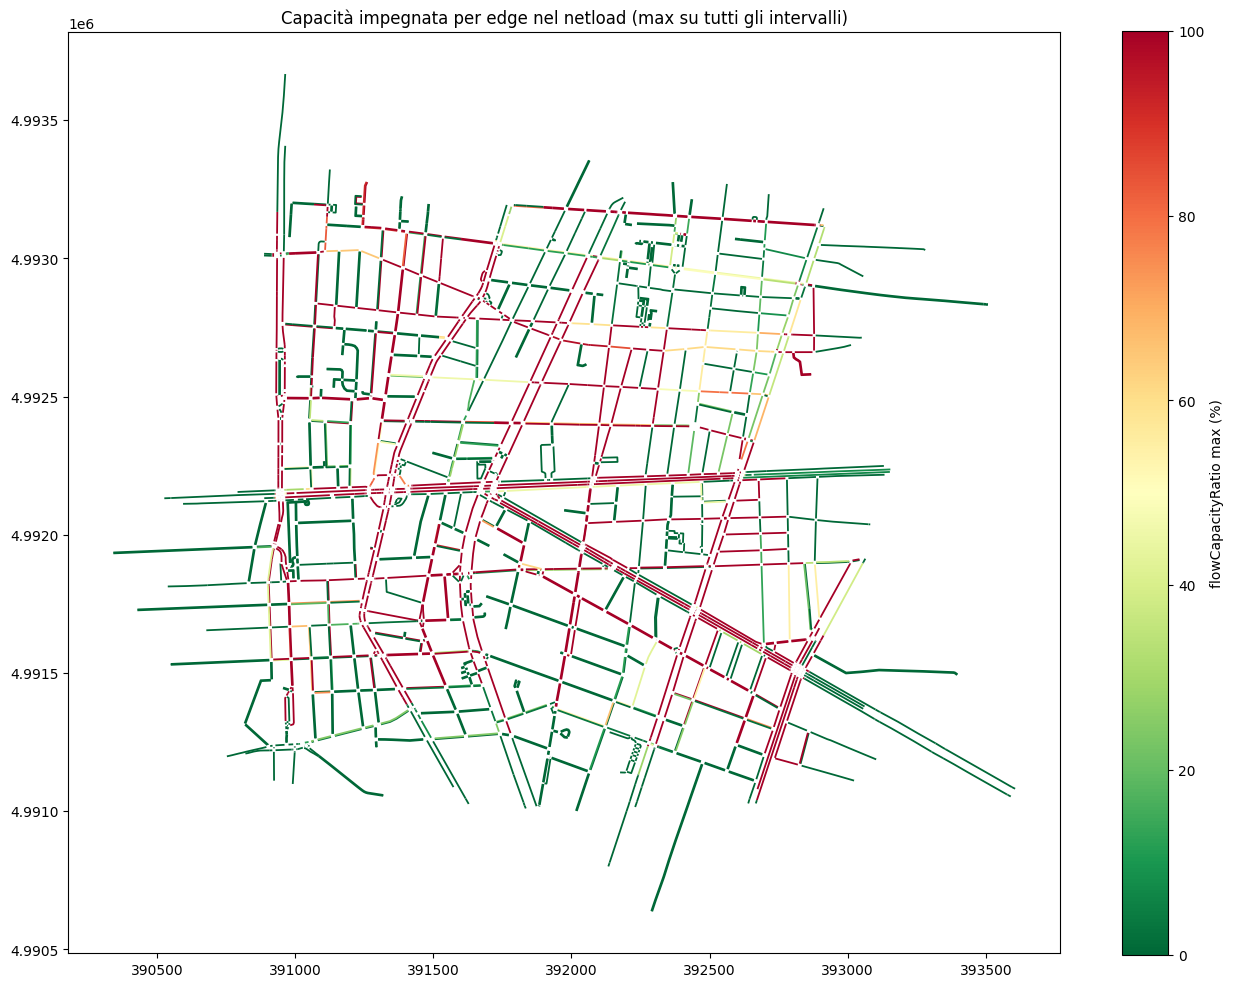

In [69]:
def plot_capacity_ratio_map(df_netload, edge_shapes, out_path=None, agg="max"):
    ratio_by_edge = df_netload.groupby("id")["flowCapacityRatio"].agg(agg)

    fig, ax = plt.subplots(figsize=(16, 12))
    norm = Normalize(vmin=0, vmax=100)
    cmap = cm.get_cmap("RdYlGn_r")

    lines, colors = [], []
    for eid, shape in edge_shapes.items():
        val = ratio_by_edge.get(eid, 0)
        lines.append(shape)
        colors.append(cmap(norm(val)))

    lc = LineCollection(lines, colors=colors, linewidths=1.3)
    ax.add_collection(lc)
    ax.autoscale()
    ax.set_aspect("equal")
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                 label=f"flowCapacityRatio {agg} (%)")
    ax.set_title(f"Capacità impegnata per edge nel netload ({agg} su tutti gli intervalli)")
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_capacity_ratio_map(df_netload, edge_shapes, agg="max")

/tmp/ipykernel_2905611/3537344190.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn_r")


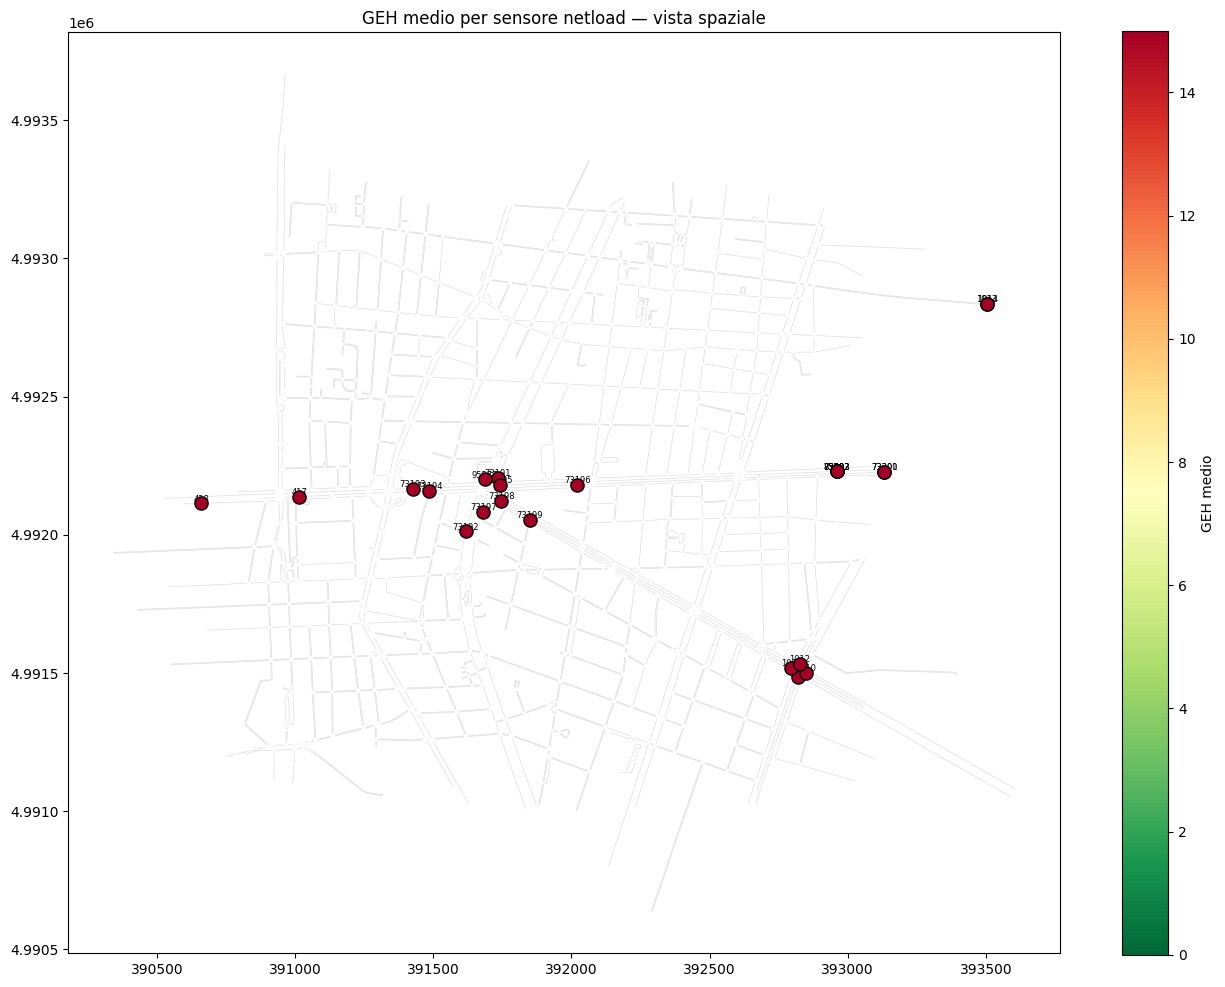

In [70]:
def plot_geh_spatial(df_geh_all, sensor_lane_lookup, net, edge_shapes, out_path=None):
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.add_collection(LineCollection(list(edge_shapes.values()), colors="#dddddd", linewidths=0.5))

    mean_geh = df_geh_all.groupby("Cod_sens")["GEH"].mean()
    cmap = cm.get_cmap("RdYlGn_r")
    norm = Normalize(vmin=0, vmax=15)

    for cod_sens, geh_val in mean_geh.items():
        rows = sensor_lane_lookup[sensor_lane_lookup["Cod_sens"] == cod_sens]
        if rows.empty:
            continue
        edge_id = rows["id_edge"].iloc[0]
        if not net.hasEdge(edge_id):
            continue
        shape = net.getEdge(edge_id).getShape()
        mid = shape[len(shape) // 2]
        ax.scatter(*mid, color=cmap(norm(geh_val)), s=90, edgecolors="black", zorder=5)
        ax.annotate(f"{cod_sens}", mid, fontsize=6, ha="center", va="bottom")

    ax.autoscale()
    ax.set_aspect("equal")
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="GEH medio")
    ax.set_title("GEH medio per sensore netload — vista spaziale")
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_geh_spatial(df_geh_all, sensor_lane_lookup, net, edge_shapes)